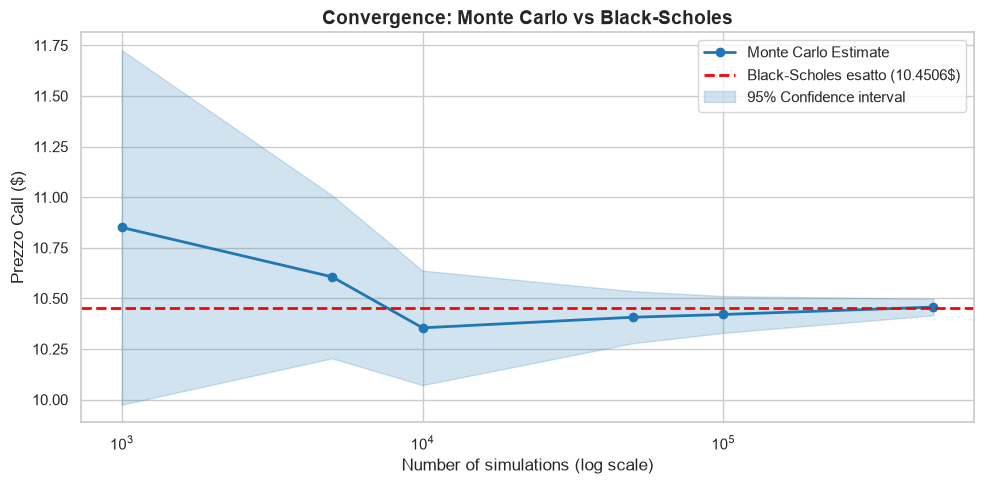

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from quant_pricing.black_scholes import BlackScholesPricer
from quant_pricing.monte_carlo import MonteCarloPricer

sns.set_theme(style="whitegrid")

# Srt parameters
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

# 1. Price BS
bs_price = BlackScholesPricer(S0, K, T, r, sigma).price("call")

# 2. Simulations with different N
simulations = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
mc_prices, mc_errors = [], []

for N in simulations:
    mc_p, mc_err = MonteCarloPricer(S0, K, T, r, sigma).price(
        "call", num_simulations=N, seed=6767
    )
    mc_prices.append(mc_p)
    mc_errors.append(mc_err)

mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    simulations,
    mc_prices,
    "o-",
    label="Monte Carlo Estimate",
    color="#1f77b4",
    linewidth=2,
)
plt.axhline(
    bs_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Black-Scholes ({bs_price:.4f}$)",
)

# 95% Confidence Interval (+/- 1.96 * SE)
plt.fill_between(
    simulations,
    mc_prices - 1.96 * mc_errors,
    mc_prices + 1.96 * mc_errors,
    color="#1f77b4",
    alpha=0.2,
    label="95% Confidence interval",
)

plt.xscale("log")
plt.title(
    "Convergence: Monte Carlo vs Black-Scholes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of simulations (log scale)", fontsize=12)
plt.ylabel("Call Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()